In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('telecom_churn_dataset.csv')
df.head()

,Index,CustomerID,Name,Tenure,MonthlyCharges,TotalCharges,InternetService,DataUsage,CustomerSupportCalls,Complaints,AutoPay,LastRechargeDaysAgo,Churn
0,1.0,CUST100000,Amit Patil,51.0,2499.0,127629.29,Cellular,36.60,4.0,1.0,Yes,82.0,Yes
1,2.0,CUST100001,Neha Gupta,23.0,399.0,9237.36,Fiber,2.82,7.0,3.0,NO,29.0,Yes
2,3.0,CUST100002,Kiran Joshi,63.0,999.0,63133.88,DSL,30.87,9.0,4.0,yes,107.0,Yes
3,4.0,CUST100003,Vikas Joshi,58.0,999.0,57901.94,Cellular,2.33,2.0,3.0,yes,54.0,No
4,5.0,CUST100004,Kiran Singh,2.0,999.0,2141.98,Fiber,34.02,8.0,1.0,NO,3.0,No


In [3]:
ds= df.copy()

# 1. Understanding data

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Index                 12575 non-null  float64
 1   CustomerID            12558 non-null  object 
 2   Name                  12560 non-null  object 
 3   Tenure                12562 non-null  float64
 4   MonthlyCharges        12564 non-null  object 
 5   TotalCharges          12559 non-null  float64
 6   InternetService       12567 non-null  object 
 7   DataUsage             12567 non-null  float64
 8   CustomerSupportCalls  12556 non-null  float64
 9   Complaints            12561 non-null  float64
 10  AutoPay               12562 non-null  object 
 11  LastRechargeDaysAgo   12571 non-null  float64
 12  Churn                 12566 non-null  object 
dtypes: float64(7), object(6)
memory usage: 1.2+ MB


In [5]:
ds.describe()

,Index,Tenure,TotalCharges,DataUsage,CustomerSupportCalls,Complaints,LastRechargeDaysAgo
count,12575.000000,12562.000000,12559.000000,12567.000000,12556.000000,12561.000000,12571.000000
mean,5988.189026,35.143926,34437.864233,24.937871,4.535839,2.005016,59.325829
std,3466.537025,20.894738,39254.972938,14.393135,2.875720,1.416764,34.736990
min,1.000000,-10.000000,-195.760000,0.000000,0.000000,0.000000,0.000000
25%,2987.500000,17.000000,8261.050000,12.550000,2.000000,1.000000,29.000000
50%,5970.000000,35.000000,20143.780000,25.020000,5.000000,2.000000,59.000000
75%,8993.500000,53.000000,45081.260000,37.325000,7.000000,3.000000,89.000000
max,12000.000000,71.000000,180283.260000,49.990000,9.000000,4.000000,119.000000


In [6]:
ds.columns= ds.columns.str.lower()

In [7]:
ds.head(2)

,index,customerid,name,tenure,monthlycharges,totalcharges,internetservice,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn
0,1.0,CUST100000,Amit Patil,51.0,2499.0,127629.29,Cellular,36.60,4.0,1.0,Yes,82.0,Yes
1,2.0,CUST100001,Neha Gupta,23.0,399.0,9237.36,Fiber,2.82,7.0,3.0,NO,29.0,Yes


# 2. Handling Missing Values

In [8]:
ds.isnull().sum()

index                   25
customerid              42
name                    40
tenure                  38
monthlycharges          36
totalcharges            41
internetservice         33
datausage               33
customersupportcalls    44
complaints              39
autopay                 38
lastrechargedaysago     29
churn                   34
dtype: int64

In [9]:
# Categorical columns
ds['internetservice'] = ds['internetservice'].fillna(ds['internetservice'].mode()[0])
ds['autopay'] = ds['autopay'].fillna(ds['autopay'].mode()[0])
ds['churn'] = ds['churn'].fillna(ds['churn'].mode()[0])

# Numeric columns
ds['index'] = ds['index'].fillna(ds['index'].mode()[0])
ds['tenure'] = ds['tenure'].fillna(ds['tenure'].mode()[0])
ds['monthlycharges'] = ds['monthlycharges'].fillna(ds['monthlycharges'].mode()[0])
ds['totalcharges'] = ds['totalcharges'].fillna(ds['totalcharges'].mode()[0])
ds['datausage'] = ds['datausage'].fillna(ds['datausage'].mode()[0])
ds['customersupportcalls'] = ds['customersupportcalls'].fillna(ds['customersupportcalls'].mode()[0])
ds['complaints'] = ds['complaints'].fillna(ds['complaints'].mode()[0])
ds['lastrechargedaysago'] = ds['lastrechargedaysago'].fillna(ds['lastrechargedaysago'].mode()[0])

In [10]:
ds.isnull().sum()

index                    0
customerid              42
name                    40
tenure                   0
monthlycharges           0
totalcharges             0
internetservice          0
datausage                0
customersupportcalls     0
complaints               0
autopay                  0
lastrechargedaysago      0
churn                    0
dtype: int64

# 3. Handling Duplicates

In [11]:
if all(col in ds.columns for col in ['customerid', 'name', 'churn']):
    ds = ds.drop_duplicates(subset=['customerid', 'name', 'churn'], keep='first')
elif all(col in ds.columns for col in ['customerid', 'churn']):
    ds = ds.drop_duplicates(subset=['customerid', 'churn'], keep='first')
else:
    ds = ds.drop_duplicates(subset=['tenure', 'monthlycharges', 'autopay', 'churn'], keep='first')

# 4. Remove Extra

In [12]:
ds.columns

Index(['index', 'customerid', 'name', 'tenure', 'monthlycharges',
       'totalcharges', 'internetservice', 'datausage', 'customersupportcalls',
       'complaints', 'autopay', 'lastrechargedaysago', 'churn'],
      dtype='object')

In [13]:
cols = [
    'tenure', 'monthlycharges', 'totalcharges',
    'internetservice', 'datausage', 'customersupportcalls',
    'complaints', 'autopay', 'lastrechargedaysago', 'churn'
]

ds = ds[cols]
ds.head(2)

,tenure,monthlycharges,totalcharges,internetservice,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn
0,51.0,2499.0,127629.29,Cellular,36.60,4.0,1.0,Yes,82.0,Yes
1,23.0,399.0,9237.36,Fiber,2.82,7.0,3.0,NO,29.0,Yes


In [14]:
ds.head()

,tenure,monthlycharges,totalcharges,internetservice,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn
0,51.0,2499.0,127629.29,Cellular,36.60,4.0,1.0,Yes,82.0,Yes
1,23.0,399.0,9237.36,Fiber,2.82,7.0,3.0,NO,29.0,Yes
2,63.0,999.0,63133.88,DSL,30.87,9.0,4.0,yes,107.0,Yes
3,58.0,999.0,57901.94,Cellular,2.33,2.0,3.0,yes,54.0,No
4,2.0,999.0,2141.98,Fiber,34.02,8.0,1.0,NO,3.0,No


# datatype correction

In [15]:
ds['monthlycharges'] = pd.to_numeric(ds['monthlycharges'], errors='coerce')

In [16]:
df.head()

,Index,CustomerID,Name,Tenure,MonthlyCharges,TotalCharges,InternetService,DataUsage,CustomerSupportCalls,Complaints,AutoPay,LastRechargeDaysAgo,Churn
0,1.0,CUST100000,Amit Patil,51.0,2499.0,127629.29,Cellular,36.60,4.0,1.0,Yes,82.0,Yes
1,2.0,CUST100001,Neha Gupta,23.0,399.0,9237.36,Fiber,2.82,7.0,3.0,NO,29.0,Yes
2,3.0,CUST100002,Kiran Joshi,63.0,999.0,63133.88,DSL,30.87,9.0,4.0,yes,107.0,Yes
3,4.0,CUST100003,Vikas Joshi,58.0,999.0,57901.94,Cellular,2.33,2.0,3.0,yes,54.0,No
4,5.0,CUST100004,Kiran Singh,2.0,999.0,2141.98,Fiber,34.02,8.0,1.0,NO,3.0,No


# 4. Extracting Features

In [17]:
ds['churn'].unique()

array(['Yes', 'No', '  No ', '  Yes '], dtype=object)

In [18]:
ds["churn"] = ds["churn"].replace(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0, '  Yes ': 1, '  No ': 0}
).astype(int)

C:\Users\Chaitanya Gaikwad\AppData\Local\Temp\ipykernel_16020\3620316604.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ds["churn"] = ds["churn"].replace(


In [19]:
ds['churn'].unique()

array([1, 0])

In [20]:
ds['churn'].value_counts()

churn
0    8689
1    3305
Name: count, dtype: int64

In [21]:
ds["autopay"].unique()

array(['Yes', 'NO', ' yes ', 'No', '   yes  ', '  NO ', '  Yes ', '  No '],
      dtype=object)

In [22]:
# str.lower() necessary
ds["autopay"] = (ds['autopay'].str.strip().str.lower().map(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0}
).astype(int))

In [23]:
ds.head()

,tenure,monthlycharges,totalcharges,internetservice,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn
0,51.0,2499.0,127629.29,Cellular,36.60,4.0,1.0,1,82.0,1
1,23.0,399.0,9237.36,Fiber,2.82,7.0,3.0,0,29.0,1
2,63.0,999.0,63133.88,DSL,30.87,9.0,4.0,1,107.0,1
3,58.0,999.0,57901.94,Cellular,2.33,2.0,3.0,1,54.0,0
4,2.0,999.0,2141.98,Fiber,34.02,8.0,1.0,0,3.0,0


# 5. Encoding

In [24]:
ds['internetservice'].unique()

array(['Cellular', 'Fiber', 'DSL', '  Cellular ', '  Fiber ', '  DSL '],
      dtype=object)

In [25]:
ds["internetservice"] = ds["internetservice"].str.strip()

In [26]:
ds['internetservice'].unique()

array(['Cellular', 'Fiber', 'DSL'], dtype=object)

In [27]:
ds['internetservice'].value_counts()

internetservice
Cellular    6567
Fiber       3553
DSL         1874
Name: count, dtype: int64

In [28]:
enc= pd.get_dummies(data=ds, columns=['internetservice'], drop_first=True, dtype=int)  # drop categorical col 1st instead in alphabetical order
ds=enc

In [29]:
ds.head()

,tenure,monthlycharges,totalcharges,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn,internetservice_DSL,internetservice_Fiber
0,51.0,2499.0,127629.29,36.60,4.0,1.0,1,82.0,1,0,0
1,23.0,399.0,9237.36,2.82,7.0,3.0,0,29.0,1,0,1
2,63.0,999.0,63133.88,30.87,9.0,4.0,1,107.0,1,1,0
3,58.0,999.0,57901.94,2.33,2.0,3.0,1,54.0,0,0,0
4,2.0,999.0,2141.98,34.02,8.0,1.0,0,3.0,0,0,1


In [30]:
print(ds.dtypes)
print(ds.head())

tenure                   float64
monthlycharges           float64
totalcharges             float64
datausage                float64
customersupportcalls     float64
complaints               float64
autopay                    int64
lastrechargedaysago      float64
churn                      int64
internetservice_DSL        int64
internetservice_Fiber      int64
dtype: object
   tenure  monthlycharges  totalcharges  datausage  customersupportcalls  \
0    51.0          2499.0     127629.29      36.60                   4.0   
1    23.0           399.0       9237.36       2.82                   7.0   
2    63.0           999.0      63133.88      30.87                   9.0   
3    58.0           999.0      57901.94       2.33                   2.0   
4     2.0           999.0       2141.98      34.02                   8.0   

   complaints  autopay  lastrechargedaysago  churn  internetservice_DSL  \
0         1.0        1                 82.0      1                    0   
1         3.0   

# 6. Train Test Split

In [31]:
X= ds.drop(columns=['churn'])
# y= ds[['churn']]
y= ds['churn']

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
X_train.shape, X_test.shape

((9595, 10), (2399, 10))

In [34]:
y_train.shape, y_test.shape

((9595,), (2399,))

# 7. Outlier remove

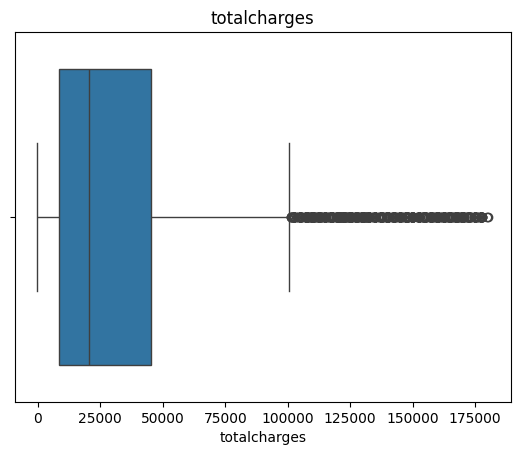

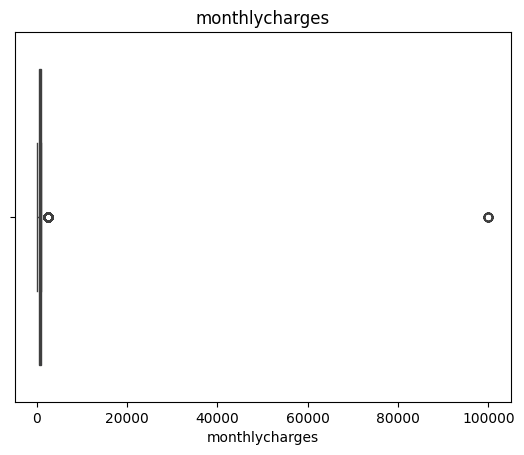

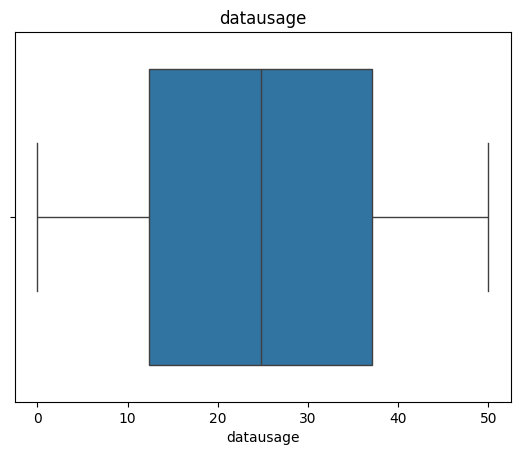

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['totalcharges', 'monthlycharges', 'datausage']:
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

In [36]:
def handle_outliers(ds, cols):
    for col in cols:
        Q1 = ds[col].quantile(0.25)
        Q3 = ds[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # clip values
        ds[col] = ds[col].clip(lower, upper)

    return ds

In [37]:
num_cols = [
    'tenure', 'monthlycharges', 'totalcharges',
    'datausage', 'customersupportcalls',
    'complaints', 'lastrechargedaysago'
]

X_train = handle_outliers(X_train, num_cols)

# 8. Scaling data

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # converted into array
X_test = scaler.transform(X_test)

# 9. Model Training

In [39]:
"""
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
"""

'\nfrom sklearn.linear_model import LogisticRegression\n\nmodel = LogisticRegression()\nmodel.fit(X_train, y_train)\n'

In [40]:
print(pd.DataFrame(X_train).isnull().sum())

0    0
1    1
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64


In [41]:
ds.head()

,tenure,monthlycharges,totalcharges,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn,internetservice_DSL,internetservice_Fiber
0,51.0,2499.0,127629.29,36.60,4.0,1.0,1,82.0,1,0,0
1,23.0,399.0,9237.36,2.82,7.0,3.0,0,29.0,1,0,1
2,63.0,999.0,63133.88,30.87,9.0,4.0,1,107.0,1,1,0
3,58.0,999.0,57901.94,2.33,2.0,3.0,1,54.0,0,0,0
4,2.0,999.0,2141.98,34.02,8.0,1.0,0,3.0,0,0,1


In [42]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [43]:
print(X_train.isnull().sum())

tenure                   0
monthlycharges           1
totalcharges             0
datausage                0
customersupportcalls     0
complaints               0
autopay                  0
lastrechargedaysago      0
internetservice_DSL      0
internetservice_Fiber    0
dtype: int64


In [44]:
X_train['monthlycharges'].fillna(X_train['monthlycharges'].median(), inplace=True)
X_test['monthlycharges'].fillna(X_train['monthlycharges'].median(), inplace=True)

C:\Users\Chaitanya Gaikwad\AppData\Local\Temp\ipykernel_16020\2063674954.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['monthlycharges'].fillna(X_train['monthlycharges'].median(), inplace=True)
C:\Users\Chaitanya Gaikwad\AppData\Local\Temp\ipykernel_16020\2063674954.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whic

In [45]:
print(X_train.isnull().sum())

tenure                   0
monthlycharges           0
totalcharges             0
datausage                0
customersupportcalls     0
complaints               0
autopay                  0
lastrechargedaysago      0
internetservice_DSL      0
internetservice_Fiber    0
dtype: int64


# again train model

In [66]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

model_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [67]:
from sklearn.ensemble import RandomForestClassifier
model_rf  = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model_rf .fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [70]:
model_svm.score(X_train, y_train)

0.7244398124022928

In [71]:
model_svm.score(X_test, y_test)

0.724468528553564

In [72]:
model_rf.score(X_train, y_train)

0.7256904637832204

In [73]:
model_rf.score(X_test, y_test)

0.724468528553564

# hyper parameter tuning

In [56]:
""""
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Step 1: Define base model
model1 = RandomForestClassifier(random_state=42)

# Step 2: Define parameter grid
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Step 3: Grid Search
grid = GridSearchCV(
    estimator=model1,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1   # use all CPU cores
)

# Step 4: Train
grid.fit(X_train, y_train)

# Step 5: Best parameters
print("Best Params:", grid.best_params_)

# Step 6: Best model
best_model = grid.best_estimator_

# Step 7: Evaluate
print("Train Score:", best_model.score(X_train, y_train))
print("Test Score:", best_model.score(X_test, y_test))
"""

'"\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import GridSearchCV\n\n# Step 1: Define base model\nmodel1 = RandomForestClassifier(random_state=42)\n\n# Step 2: Define parameter grid\nparams = {\n    \'n_estimators\': [100, 200, 300],\n    \'max_depth\': [5, 10, 15, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 5],\n    \'max_features\': [\'sqrt\', \'log2\']\n}\n\n# Step 3: Grid Search\ngrid = GridSearchCV(\n    estimator=model1,\n    param_grid=params,\n    cv=5,\n    scoring=\'accuracy\',\n    n_jobs=-1   # use all CPU cores\n)\n\n# Step 4: Train\ngrid.fit(X_train, y_train)\n\n# Step 5: Best parameters\nprint("Best Params:", grid.best_params_)\n\n# Step 6: Best model\nbest_model = grid.best_estimator_\n\n# Step 7: Evaluate\nprint("Train Score:", best_model.score(X_train, y_train))\nprint("Test Score:", best_model.score(X_test, y_test))\n'

In [57]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:24:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [58]:
model_xgb.score(X_train, y_train)

0.7570609692548202

In [59]:
model_xgb.score(X_test, y_test)

0.716548561900792

In [80]:
models = {
    "SVM": model_svm,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

best_model = None
best_score = 0

print("\n===== MODEL COMPARISON =====\n")

for name, model in models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"{name}")
    print(f"Training Accuracy : {train_score:.4f}")
    print(f"Testing Accuracy  : {test_score:.4f}")
    print("-" * 35)

    # Select Best Model
    if test_score > best_score:
        best_score = test_score
        best_model = name

print(f"\nBest Model : {best_model}")
print(f"Best Accuracy : {best_score:.4f}")


===== MODEL COMPARISON =====

SVM
Training Accuracy : 0.7244
Testing Accuracy  : 0.7245
-----------------------------------
Random Forest
Training Accuracy : 0.7257
Testing Accuracy  : 0.7245
-----------------------------------
XGBoost
Training Accuracy : 0.7571
Testing Accuracy  : 0.7165
-----------------------------------

Best Model : SVM
Best Accuracy : 0.7245


In [60]:
new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

# Numeric values
new_customer['tenure'] = 40
new_customer['monthlycharges'] = 799
new_customer['totalcharges'] = 32000
new_customer['datausage'] = 25.5
new_customer['customersupportcalls'] = 3
new_customer['complaints'] = 1
new_customer['lastrechargedaysago'] = 20

# Encoded categorical values
new_customer['autopay'] = 1
new_customer['internetservice_DSL'] = 0
new_customer['internetservice_Fiber'] = 1

In [61]:
new_customer_scaled = scaler.transform(new_customer)

In [81]:
best_model_object = models[best_model]
prediction = best_model_object.predict(new_customer_scaled)

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy       : {best_accuracy:.4f}")

if prediction[0] == 1:
    print("\nPrediction : Customer will leave")
else:
    print("\nPrediction : Customer will stay")


Best Model Selected : SVM
Best Accuracy       : 0.7245

Prediction : Customer will stay


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [84]:
prob = best_model_object.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"Stay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

Stay Probability  : 72.41%
Leave Probability : 27.59%


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [86]:
# =========================================
# Hyperparameter Tuning For XGBoost
# =========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================
# XGBoost Parameter Grid
# =========================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# =========================================
# Base XGBoost Model
# =========================================

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# =========================================
# Randomized Search CV
# =========================================

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# =========================================
# Train Tuned Model
# =========================================

random_search.fit(X_train, y_train)

# =========================================
# Best Parameters
# =========================================

print("\nBest Parameters:\n")
print(random_search.best_params_)

# =========================================
# Best Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# =========================================
# Accuracy Scores
# =========================================

train_score = best_xgb.score(X_train, y_train)
test_score = best_xgb.score(X_test, y_test)

print("\nTraining Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

# =========================================
# Prediction Using Tuned XGBoost
# =========================================

new_customer_scaled = scaler.transform(new_customer)

prediction = best_xgb.predict(new_customer_scaled)

if prediction[0] == 1:
    print("\nCustomer will leave")
else:
    print("\nCustomer will stay")

# =========================================
# Probability Prediction
# =========================================

prob = best_xgb.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:58:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters:

{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Training Accuracy : 0.7244398124022928
Testing Accuracy  : 0.724468528553564

Customer will stay

Stay Probability  : 71.96%
Leave Probability : 28.04%


In [88]:
import joblib

# Save SVM Model
joblib.dump(model_svm, "subscription_svm_model.pkl")

# Save Scaler
joblib.dump(scaler, "subscription_scaler.pkl")

print("SVM Model Saved Successfully")
print("Scaler Saved Successfully")

SVM Model Saved Successfully
Scaler Saved Successfully


In [64]:
ds

,tenure,monthlycharges,totalcharges,datausage,customersupportcalls,complaints,autopay,lastrechargedaysago,churn,internetservice_DSL,internetservice_Fiber
0,51.0,2499.0,127629.29,36.60,4.0,1.0,1,82.0,1,0,0
1,23.0,399.0,9237.36,2.82,7.0,3.0,0,29.0,1,0,1
2,63.0,999.0,63133.88,30.87,9.0,4.0,1,107.0,1,1,0
3,58.0,999.0,57901.94,2.33,2.0,3.0,1,54.0,0,0,0
4,2.0,999.0,2141.98,34.02,8.0,1.0,0,3.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
11995,38.0,2499.0,94894.05,29.61,3.0,1.0,0,18.0,0,0,1
11996,8.0,1027.0,8180.77,45.38,9.0,0.0,1,61.0,0,0,1
11997,59.0,399.0,23669.02,6.24,2.0,3.0,1,0.0,0,0,1
11998,38.0,999.0,38123.12,7.93,8.0,0.0,1,89.0,1,0,1


# accuracy

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    # Train
    model1.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print("🔹 Train Accuracy:", train_acc)
    print("🔹 Test Accuracy:", test_acc)
    
    # Classification report
    print("\n🔹 Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))
    
    # Confusion matrix
    print("\n🔹 Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    
    return model